- 퍼셉트론
  - 퍼센트론은 신경망(딥러닝)의 기원이 되는 알고리즘
  - 기본 구조
    - 퍼셉트론은 여러 신호를 입력 받아 하나의 신호(0 또는 1)를 출력
    - 입력이 2개인 경우
        ```
        
         x1 ──(w1)──┐
                    ├──▶ [ y ]
         x2 ──(w2)──┘
         
        ```
      - x1, x2: 입력 신호
      - w1, w2: 가중치(weight), 각 입력이 결과에 얼마나 중요한지를 나타냄
      - y: 출력 신호 (0 또는 1)

- 동작 방식을 다음과 같음
```
        ┌ 0   (w1·x1 + w2·x2 ≤ θ)
  y  =  ┤
        └ 1   (w1·x1 + w2·x2 > θ)
```
- 입력과 가중치를 곱한 값의 합이 임계값 θ(세타)를 넘으면 1을 출력하고, 이를 뉴런이 "활성화 한다(발화한다)"고 표현

- 가중치의 의미
  - 가중치가 클수록 해당 입력이 출력에 미치는 영향이 커짐,
  - 예를 들어 w1=1.0, w2=0.1 이라면 x1이 1일 때는 결과가 크게 바뀌지만 x2는 거의 영향을 주지 못함
  - 전기회로에 비유하면 가중치는 전류가 흐르는 정보(저항의 역수)에 해당

- 임계값을 편향으로 바꾸기
  - 실제 구현에서는 θ를 좌변으로 옮겨 b = -θ로 두고 이를 편향(bias) 이라 부름
      ```
      
            ┌ 0   (b + w1·x1 + w2·x2 ≤ 0)
      y  =  ┤
            └ 1   (b + w1·x1 + w2·x2 > 0)
            
      ```
  - 수식적으로는 같은 식이지만 역할이 다르게 해석
    | 매개변수 | 역할 |
    | --- | --- |
    | 가중치 w | 각 입력 신호의 중요도 조절 |
    | 편향 b | 뉴런이 얼마나 쉽게 활성화되는 지 조절 |
    - b = -0.1 -> 가중합이 0.1만 넘어도 활성화 (쉽게 켜짐)
    - b = -20.0 -> 가중합이 20을 넘어야 활성화 (잘 안켜짐)
 - 이 "가중합 + 편향" 구조는 신경망에서도 그대로 이어짐

In [1]:
import numpy as np

x = np.array([0, 1])      # 입력
w = np.array([0.5, 0.5])  # 가중치
b = -0.7                  # 편향

print(w * x)
print(np.sum(w * x))
print(np.sum(w * x) + b)

[0.  0.5]
0.5
-0.19999999999999996


결과가 0 이하 이므로 이 경우 출력은 0

- 단순한 논리 회로 구현: AND, NAND, OR
  - 퍼셉트론의 구조는 그대로 두고 매개변수(w1, w2, b)만 바꾸면 서로 다른 논리 회로가 됨

- 진리표
| x1 | x2 | AND | NAND | OR |
| --- | --- | --- | --- | --- |
| 0 | 0 | 0 | 1 | 0 |
| 1 | 0 | 0 | 1 | 1 |
| 0 | 1 | 0 | 1 | 1 |
| 1 | 1 | 1 | 0 | 1 |

  - AND: 둘다 1일 때만 1
  - NAND(Not AND): AND 의 반대, 둘다 1일때만 0
  - OR: 하나라도 1이면 1

- 매개변수 직접 정해보기
  - AND는 (1, 1)일 때만 가중합이 기준을 넘어야 함, 예를 들어  w1=w2=0.5, b=-0.7로 진행
    | x1 | x2 | 0.5 * x1 + 0.5 * x2 - 0.7 | y |
    | --- | --- | --- | --- |
    | 0 | 0 | -0.7 | 0 |
    | 1 | 0 | -0.2 | 0 |
    | 0 | 1 | -0.2 | 0 |
    | 1 | 1 | 0.3 | 1 |
  - 진리표와 일치, 이 조합은 정답이 하나가 아님
  - (w1, w2, b) = (1.0, 1.0, -1.5)나 (0.5, 0.5, -0.8)도 AND로 동작
    
  - NAND는 AND의 매개변수 부호를 전부 뒤집으면 됨, 예를 들어 (-0.5, -0.5, 0.7)
    | x1 | x2 | -0.5 * x1 - 0.5 * x2 + 0.7 | y |
    | --- | --- | --- | --- |
    | 0 | 0 | 0.7 | 1 |
    | 1 | 0 | 0.2 | 1 |
    | 0 | 1 | 0.2 | 1 |
    | 1 | 1 | -0.3 | 0 |
        
  - OR는 입력 하나만 1이어도 기준을 넘도록 편향을 작게(절대값을) 잡으면 됨 (0.5, 0.5, 0.2)
    | x1 | x2 | 0.5 * x1 + 0.5 * x2 - 0.2 | y |
    | --- | --- | --- | --- |
    | 0 | 0 | -0.2 | 0 |
    | 1 | 0 | 0.3 | 1 |
    | 0 | 1 | 0.3 | 1 |
    | 1 | 1 | 0.8 | 1 |

  - 현재는 매개변수를 사람이 진리표를 보고 직접 정했지만, 추후에 자동으로 찾게(학습)함

In [2]:
import numpy as np

def AND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.7
    tmp = np.sum(w * x) + b

    return 1 if tmp > 0 else 0

def NAND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([-0.5, -0.5])     # AND와 부호만 반대
    b = 0.7
    tmp = np.sum(w * x) + b

    return 1 if tmp > 0 else 0

def OR(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])       # AND와 가중치는 같고
    b = -0.2                       # 편향만 다름
    tmp = np.sum(w * x) + b

    return 1 if tmp > 0 else 0

inputs = [(0, 0), (1, 0), (0, 1), (1, 1)]
for gate in (AND, NAND, OR):
    results = [gate(x1, x2) for x1, x2 in inputs]
    print(f"{gate.__name__:5s}: {results}")

AND  : [0, 0, 0, 1]
NAND : [1, 1, 1, 0]
OR   : [0, 1, 1, 1]


- 세 함수는 코드 구조가 완전히 같고 w와 b의 값만 다름, 아래처럼 하나의 범용함수로도 작성 가능

In [ ]:
# def perceptron(x, w, b):
#     return 1 if np.dot(w, x) + b > 0 else 0

# AND  = lambda x1, x2: perceptron([x1, x2], [0.5, 0.5], -0.7)
# NAND = lambda x1, x2: perceptron([x1, x2], [-0.5, -0.5], 0.7)
# OR   = lambda x1, x2: perceptron([x1, x2], [0.5, 0.5], -0.2)

# inputs = [(0, 0), (1, 0), (0, 1), (1, 1)]
# for gate in (AND, NAND, OR):
#     results = [gate(x1, x2) for x1, x2 in inputs]
#     print(f"{gate.__name__:5s}: {results}")

- 퍼셉트론의 한계: XOR 문제
  - XOR 게이트
    - XOR(배타적 논리합)은 두 입력 중 한쪽만 1일때 1을 출력
      | x1 | x2 | XOR |
      | --- | --- | --- |
      | 0 | 0 | 0 |
      | 1 | 0 | 1 |
      | 0 | 1 | 1 |
      | 1 | 1 | 0 |
    - 아무리 w1, w2, b를 변경해도 단층 퍼셉트론으로는 XOR을 만들 수 없음

- 퍼셉트론은 직선 하나 로 공간을 나눔
  - XOR 게이트(w1=w2=1, b=-0.5)를 예로 들면 퍼셉트론 식은
  - y = 1 (-0.5 + x1 + x2 > 0)
  - y = 0 (-0.5 + x1 + x2 <= 0)
  - 이고 경계인 -0.5 + x1 + x2 = 0 은 평면 위의 직선, 이 직선의 한쪽은 1, 반대쪽은 0이 됨
  ```
      
     OR (직선으로 분리 가능)           XOR (직선으로 분리 불가)
    
     x2                               x2
     1 │ ▲        ▲                   1 │ ▲        ●
       │  ╲                             │
       │   ╲                            │
     0 │ ●  ╲     ▲                   0 │ ●        ▲
       └──────────── x1                 └──────────── x1
         0         1                      0         1
    
     ● = 출력 0,  ▲ = 출력 1
            
  ```
  - OR: 점(0, 0) 하나만 직선 한쪽에 떼어 놓으면 분리 가능
  - XOR: 점(0, 0)과 점(1, 1)이 대각선으로, 점(1, 0)과 점(0, 1)이 반대 대각선으로 놓여 있어서 어떤 직선으로도 분리 불가능

- 선형과 비선형
  - 선형 영역: 직선(고차원에서서는 평며/초평면)으로 나뉜 영역
  - 비선형 영역: 곡선 등으로 나뉜 영역
- XOR은 곡선으로라면 나눌 수 있지만, 단층 퍼셉트론은 선형 영역만 표현할 수 있기 때문에 나눌수 없음
- 이것이 퍼셉트론의 한계

결정 경계 구현

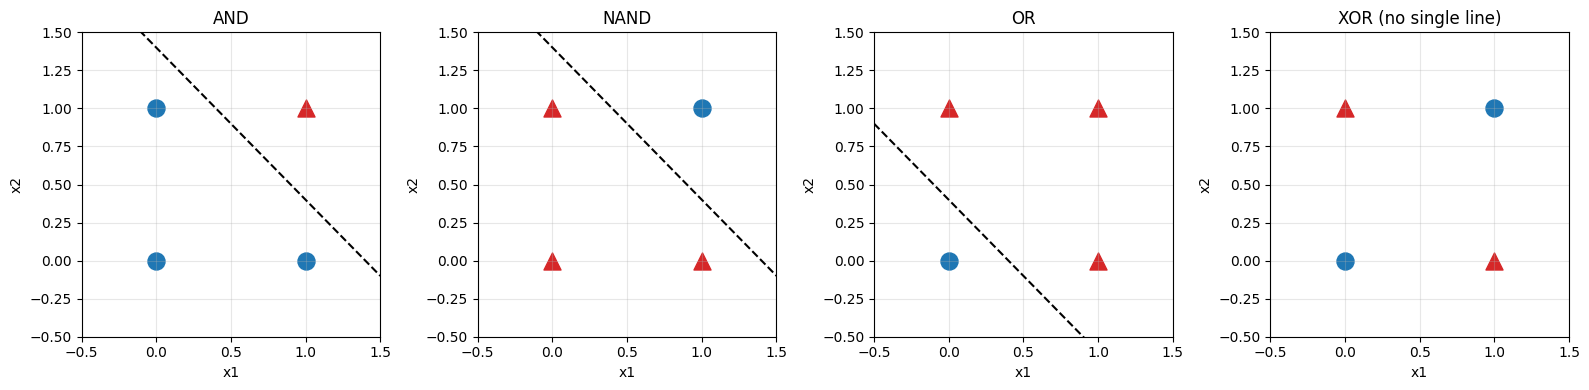

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gate(ax, title, w, b, labels):
    pts = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])
    for (x1, x2), y in zip(pts, labels):
        ax.scatter(x1, x2, s=150, marker='^' if y == 1 else 'o', c="tab:red" if y == 1 else "tab:blue")
    if w is not None:
        # w1 * x1 + w2 * x2 + b = 0 -> x2 = -(w1 * x1 + b) / w2
        xs = np.linspace(-0.5, 1.5, 100)
        ax.plot(xs, -(w[0] * xs + b) / w[1], "k--")

    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_title(title); ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plot_gate(axes[0], "AND", [0.5, 0.5], -0.7, [0, 0, 0, 1])
plot_gate(axes[1], "NAND", [-0.5, -0.5], 0.7, [1, 1, 1, 0])
plot_gate(axes[2], "OR", [0.5, 0.5], -0.2, [0, 1, 1, 1])
plot_gate(axes[3], "XOR (no single line)", None, None, [0, 1, 1, 0])
plt.tight_layout()
plt.show()

- 다층 퍼셉트론으로 XOR 해결
  - 기존 게이트를 조합한다
  - 단층으로는 안되지만, 층을 쌓으면 XOR을 만들 수 있슴
  - XOR(x1, x2) = AND(NAND(x1, x2), OR(x1, x2))
  ```
      
     x1 ──┬──▶ [NAND] ── s1 ──┐
          │                   ├──▶ [AND] ──▶ y
     x2 ──┴──▶ [ OR ] ── s2 ──┘
            
  ```
  - 진리표로 검증
  | x1 | x2 | s1 = NAND | s2 = OR | y = AND(s1, s2) |
| --- | --- | --- | --- | --- |
| 0 | 0 | 1 | 0 | 0 |
| 1 | 0 | 1 | 1 | 1 |
| 0 | 1 | 1 | 1 | 1 |
| 1 | 1 | 0 | 1 | 0 |
  - 마지막 열이 XOR 진리표와 정확히 일치
  - 직관적으로 보면
    - OR은 적어도 하나는 1을 걸러내고
    - NAND는 둘다 1은 아님을 걸러내며
    - AND가 두 조건을 동시에 만족하는 경우만 남김 -> 정확히 하나만 1 = XOR
  - 기하학적으로는 NAND와 OR이 각각 직선 하나씩, 통 두 개의 직선을 긋고, 그 두 직선 사이의 띠 영역을 AND가 골라내는 셈
  - 직선 하나로는 불가능했던 비선형 분리를 층을 쌓아 해결

In [5]:
def XOR(x1, x2):
    s1 = NAND(x1, x2)   # 1층
    s2 = OR(x1, x2)     # 1층
    y = AND(s1, s2)     # 2층

    return y

for x1, x2 in [(0, 0), (1, 0), (0, 1), (1, 1)]:
    print(f"XOR({x1}, {x2}) = {XOR(x1, x2)}")

XOR(0, 0) = 0
XOR(1, 0) = 1
XOR(0, 1) = 1
XOR(1, 1) = 0


- 층 세는 법
  - 이 구조를 뉴런 그림으로 그리면 3개의 층이 보임
  ```
      
  0층(입력)       1층            2층(출력)
   x1  ─────▶   s1 (NAND)  ─┐
        ╲ ╱                 ├──▶  y (AND)
        ╱ ╲                 │
   x2  ─────▶   s2 (OR)    ─┘
            
  ```
  - 0층 -> 1층, 1층 -> 2층으로 가중치를 가진 층은 2개, 2층 퍼셉트론
  - 이렇게 층이 여러개인 퍼셉트론을 다층 퍼셉트론(MLP, multi-layer perceptron) 이라고 함

- 층을 쌓으면 표현력이 커짐: NAND에서 컴퓨터까지
  - NAND게이트만 조합하면 컴퓨터가 하는 모든 논리 연산을 만들 수 있음
  - 퍼셉트론은 NAND를 표현할 수 있으므로, 퍼셉트론을 충분히 조합하면 이론적으로 컴퓨터 자체를 표현 가능
  - 더 나아가 이론적으로는 2층 퍼셉트론만으로도 임의의 함수를 표현할 수 있음이 알려져 있음
  - 단 이는 활성화 함수로 시그로이드 같은 비선형 함수를 쓰는 경우의 이야기
  - 실제로는 2층으로 복잡한 기능을 만들려면 가중치 설계가 어렵기 때문에 층을 깊게 쌓아 단계적으로 문제를 쪼개는 방식이 효과적

In [12]:
import numpy as np

# 범용 퍼셉트론: 가중합 + 편향이 0보다 크면 1
def perceptron(x, w, b):
    x, w = np.array(x), np.array(w)
    return 1 if np.sum(w * x) + b > 0 else 0

# 단층 퍼셉트론: 매개변수만 다르다
def AND(x1, x2): return perceptron([x1, x2], [0.5, 0.5], -0.7)
def NAND(x1, x2): return perceptron([x1, x2], [-0.5, -0.5], 0.7)
def OR(x1, x2): return perceptron([x1, x2], [0.5, 0.5], -0.2)

# 2층 퍼셉트론: 게이트를 쌓아서 XOR 구현
def XOR(x1, x2):
    s1 = NAND(x1, x2)
    s2 = OR(x1, x2)
    return AND(s1, s2)

inputs = [(0, 0), (1, 0), (0, 1), (1, 1)]
print("x1 x2 | AND NAND OR XOR")
print("------+----------------")
for x1, x2 in inputs:
    print(f" {x1}  {x2} | {AND(x1, x2)}    {NAND(x1, x2)}    "
          f"{OR(x1, x2)}   {XOR(x1, x2)}")

x1 x2 | AND NAND OR XOR
------+----------------
 0  0 | 0    1    0   0
 1  0 | 0    1    1   1
 0  1 | 0    1    1   1
 1  1 | 1    0    1   0


- 핵심 요약
  1. 퍼셉트론은 입력 x 가중치의 합에 편향을 더해, 0보다 트면 1을 출력하는 알고리즘
  2. 가중치는 입력의 중요도, 편향은 활성화되는 쉬움을 조절
  3. 같은 구조로 매개변수만 바꾸면 AND, NAND, OR을 모두 만들수 있음
  4. 단층 퍼셉트론은 직선 하나(선형영역)만 표현하므로 XOR을 만들 수 없다
  5. 층을 다층 퍼셉트론은 비선형 영역을 표현할 수 있어 XOR이 가능
  6. 매개변수의 경우 현재는 사람이 직접 정하고 있지만, 데이터로 부터 학습하게 진행되어야 함